# 7. Balanceo de clases

El proyecto incluye implementar y comparar tres estrategias de balanceo
sobre los modelos de clasificación:

- **SMOTE** (Synthetic Minority Over-sampling Technique)
 {cite}`chawla2002smote` — genera ejemplos sintéticos de la clase
 minoritaria interpolando entre vecinos.
- **ADASYN** (Adaptive Synthetic Sampling) — variante de SMOTE que
 genera más muestras donde la clase minoritaria es "difícil"
 (rodeada de muchos vecinos de la clase mayoritaria).
- **`class_weight='balanced'`** — sin remuestreo; el estimador
 asigna pesos inversos a la frecuencia de cada clase en la función
 de pérdida.

## 7.1 Caracterización del desbalance en este dataset

Antes de aplicar las técnicas, conviene entender la naturaleza
exacta del problema:

| Conjunto | Clase 0 (bajo) | Clase 1 (alto) |
|---|---|---|
| train | **50.0%** | **50.0%** |
| val | 86.6% | 13.4% |
| test | 89.6% | 10.4% |

Tres observaciones críticas:

1. **El train está balanceado por construcción.** El umbral del
 régimen es la mediana de `target_vol` calculada en train, lo que
 produce exactamente 50/50 en train.
2. **El desbalance es de val y test.** Aparece por *distribution
 shift*: la volatilidad post-2008 fue históricamente más baja que
 la del período 1990-2008, así que aplicar el umbral del train a
 datos posteriores deja la mayoría como "régimen bajo".
3. **No es desbalance "de clase" en el sentido clásico** del problema
 de aprendizaje. Las técnicas SMOTE / ADASYN / `class_weight` están
 diseñadas para corregir desbalance en el conjunto de entrenamiento,
 no para corregir distribution shift.

## 7.2 Hipótesis empírica del capítulo

Si SMOTE, ADASYN y `class_weight='balanced'` se aplican a un train
ya balanceado 50/50, su efecto sobre las métricas de test debería
ser **marginal**. La hipótesis a contrastar es:

> *No hay diferencias significativas en AUC test entre baseline
> (sin balanceo, NB 06) y las tres variantes con balanceo, porque
> el train no requiere ser balanceado.*

Si se confirma, el hallazgo vale la pena: **el
distribution shift no se corrige rebalanceando el train**.

## 7.3 Experimento adicional: cuándo funciona el balanceo

Para demostrar que estas técnicas funcionan cuando se aplican al
caso para el que fueron diseñadas, replicamos el experimento sobre
un train artificialmente desbalanceado: sub-sampleo la clase 1 del
train para llevarlo de 50/50 a 90/10 (imitando el ratio del test),
y luego aplico las cuatro variantes (baseline, SMOTE, ADASYN,
balanced). Si las técnicas funcionan donde se las necesita, debería
verse mejora clara en F1 y recall sobre el test.

## 7.4 Anti-leakage

Toda técnica de remuestreo aplicada vía `imblearn.pipeline.Pipeline`:
SMOTE / ADASYN se ejecutan solo en `fit()` del pipeline, no en
`predict()` ni en `transform()`. Esto garantiza que el val y el
test nunca son alterados por las técnicas de balanceo.

Para XGBoost, que requiere preprocesamiento manual por el early
stopping, aplicamos el remuestreo manualmente solo sobre el train
ya escalado (val transformado intacto como `eval_set`).


## 7.5 Setup y carga

In [1]:
import sys
from pathlib import Path
import time
import warnings
import json
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
)
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    RANDOM_STATE, METRICS_DIR, PREDICTIONS_DIR, MODELS_DIR,
    FIGURES_DIR, TABLES_DIR, ensure_dirs,
)
from src.viz import set_style, savefig
from src.io_utils import save_json, save_model

ensure_dirs()
set_style()
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(RANDOM_STATE)


In [2]:
tr = pd.read_parquet(PROJECT_ROOT / "data/processed/train.parquet")
va = pd.read_parquet(PROJECT_ROOT / "data/processed/val.parquet")
te = pd.read_parquet(PROJECT_ROOT / "data/processed/test.parquet")

with open(PROJECT_ROOT / "data/processed/metadata.json") as f:
    meta = json.load(f)
feature_cols = meta["feature_columns"]

def split_xy(df, cols):
    mask = df["target_regime"].notna()
    return (
        df.loc[mask, cols].to_numpy(),
        df.loc[mask, "target_regime"].astype(int).to_numpy(),
    )

X_train, y_train = split_xy(tr, feature_cols)
X_val,   y_val   = split_xy(va, feature_cols)
X_test,  y_test  = split_xy(te, feature_cols)

print(f"Train: {X_train.shape} | clases: {dict(zip(*np.unique(y_train, return_counts=True)))} | tasa_pos = {y_train.mean():.3f}")
print(f"Val:   {X_val.shape} | clases: {dict(zip(*np.unique(y_val, return_counts=True)))} | tasa_pos = {y_val.mean():.3f}")
print(f"Test:  {X_test.shape} | clases: {dict(zip(*np.unique(y_test, return_counts=True)))} | tasa_pos = {y_test.mean():.3f}")


Train: (4873, 31) | clases: {np.int64(0): np.int64(2434), np.int64(1): np.int64(2439)} | tasa_pos = 0.501
Val:   (1044, 31) | clases: {np.int64(0): np.int64(904), np.int64(1): np.int64(140)} | tasa_pos = 0.134
Test:  (1045, 31) | clases: {np.int64(0): np.int64(936), np.int64(1): np.int64(109)} | tasa_pos = 0.104


## 7.6 Helpers

Definimos dos helpers. El primero entrena un pipeline imblearn
(que ya incluye el resampler) y evalúa. El segundo genera, para un
estimador y una técnica de balanceo, el pipeline correspondiente.

In [3]:
def metrics_5(y_true, y_pred, y_proba):
    return {
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "auc":       float(roc_auc_score(y_true, y_proba)),
    }

def fit_and_eval(name, pipeline,
                 X_train, y_train, X_val, y_val, X_test, y_test):
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    fit_s = time.time() - t0
    proba_val  = pipeline.predict_proba(X_val)[:,  1]
    proba_test = pipeline.predict_proba(X_test)[:, 1]
    pred_val   = pipeline.predict(X_val)
    pred_test  = pipeline.predict(X_test)
    m_val  = metrics_5(y_val,  pred_val,  proba_val)
    m_test = metrics_5(y_test, pred_test, proba_test)
    return {
        "name": name, "fit_s": fit_s,
        **{f"{k}_val":  v for k, v in m_val.items()},
        **{f"{k}_test": v for k, v in m_test.items()},
        "proba_val": proba_val, "proba_test": proba_test,
        "pred_val":  pred_val,  "pred_test":  pred_test,
    }


In [4]:
# Diccionario base de estimadores. class_weight se aplica donde aplica.
def make_estimators(use_class_weight=False):
    cw = "balanced" if use_class_weight else None
    return {
        "knn":         KNeighborsClassifier(n_neighbors=15, weights="uniform", n_jobs=-1),
        "gaussian_nb": GaussianNB(),
        "logreg_l1":   LogisticRegression(penalty="l1", solver="saga", C=1.0,
                                          max_iter=5000, class_weight=cw,
                                          random_state=RANDOM_STATE),
        "logreg_l2":   LogisticRegression(penalty="l2", solver="saga", C=1.0,
                                          max_iter=5000, class_weight=cw,
                                          random_state=RANDOM_STATE),
        "tree":        DecisionTreeClassifier(max_depth=8, min_samples_leaf=10,
                                              class_weight=cw,
                                              random_state=RANDOM_STATE),
        "rf":          RandomForestClassifier(n_estimators=200, max_depth=10,
                                              min_samples_leaf=5, max_features="sqrt",
                                              class_weight=cw,
                                              random_state=RANDOM_STATE, n_jobs=-1),
        "svm":         SVC(kernel="rbf", C=1.0, gamma="scale", probability=True,
                           class_weight=cw, random_state=RANDOM_STATE),
    }

def make_pipeline(estimator, balancer=None):
    # imblearn.Pipeline aplica balancer solo en fit, no en predict.
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]
    if balancer is not None:
        steps.append(("balancer", balancer))
    steps.append(("model", estimator))
    return ImbPipeline(steps) if balancer is not None else SkPipeline(steps)


## 7.7 Experimento 1 — Train balanceado real (50/50)

Aplicamos las cuatro variantes a los siete modelos clasificadores
clásicos del NB 06 (excluyendo XGBoost que se trata aparte por el
early stopping).

Los modelos KNN y GaussianNB no aceptan `class_weight`. Para ellos,
omitimos la variante "balanced" y solo evaluamos baseline, SMOTE
y ADASYN.


In [5]:
results_exp1 = {}  # (model, technique) -> dict

# (1) Baseline — sin balanceo
print("=== Baseline ===")
estimators = make_estimators(use_class_weight=False)
for name, est in estimators.items():
    r = fit_and_eval(f"{name}_baseline",
                     make_pipeline(est, balancer=None),
                     X_train, y_train, X_val, y_val, X_test, y_test)
    results_exp1[(name, "baseline")] = r
    print(f"  {name:>12s} | AUC_test={r['auc_test']:.4f} F1={r['f1_test']:.4f} Rec={r['recall_test']:.4f}")


=== Baseline ===


           knn | AUC_test=0.8393 F1=0.4384 Rec=0.2936


   gaussian_nb | AUC_test=0.8703 F1=0.5455 Rec=0.4128


     logreg_l1 | AUC_test=0.9443 F1=0.7708 Rec=0.6789


     logreg_l2 | AUC_test=0.9442 F1=0.7708 Rec=0.6789
          tree | AUC_test=0.9251 F1=0.7053 Rec=0.6147


            rf | AUC_test=0.9559 F1=0.8061 Rec=0.7248


           svm | AUC_test=0.9136 F1=0.6532 Rec=0.7431


In [6]:
# (2) SMOTE
print("\n=== SMOTE ===")
estimators = make_estimators(use_class_weight=False)
for name, est in estimators.items():
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    r = fit_and_eval(f"{name}_smote",
                     make_pipeline(est, balancer=smote),
                     X_train, y_train, X_val, y_val, X_test, y_test)
    results_exp1[(name, "smote")] = r
    print(f"  {name:>12s} | AUC_test={r['auc_test']:.4f} F1={r['f1_test']:.4f} Rec={r['recall_test']:.4f}")



=== SMOTE ===
           knn | AUC_test=0.8391 F1=0.4384 Rec=0.2936


   gaussian_nb | AUC_test=0.8703 F1=0.5455 Rec=0.4128


     logreg_l1 | AUC_test=0.9442 F1=0.7708 Rec=0.6789


     logreg_l2 | AUC_test=0.9441 F1=0.7708 Rec=0.6789
          tree | AUC_test=0.9252 F1=0.7053 Rec=0.6147


            rf | AUC_test=0.9576 F1=0.7938 Rec=0.7064


           svm | AUC_test=0.9137 F1=0.6586 Rec=0.7523


In [7]:
# (3) ADASYN
print("\n=== ADASYN ===")
estimators = make_estimators(use_class_weight=False)
for name, est in estimators.items():
    adasyn = ADASYN(random_state=RANDOM_STATE, n_neighbors=5)
    try:
        r = fit_and_eval(f"{name}_adasyn",
                         make_pipeline(est, balancer=adasyn),
                         X_train, y_train, X_val, y_val, X_test, y_test)
        results_exp1[(name, "adasyn")] = r
        print(f"  {name:>12s} | AUC_test={r['auc_test']:.4f} F1={r['f1_test']:.4f} Rec={r['recall_test']:.4f}")
    except ValueError as e:
        # ADASYN puede fallar si la clase minoritaria no es bastante diversa
        print(f"  {name:>12s} | ADASYN FALLÓ: {e}")
        results_exp1[(name, "adasyn")] = None



=== ADASYN ===
           knn | ADASYN FALLÓ: No samples will be generated with the provided ratio settings.
   gaussian_nb | ADASYN FALLÓ: No samples will be generated with the provided ratio settings.


     logreg_l1 | ADASYN FALLÓ: No samples will be generated with the provided ratio settings.
     logreg_l2 | ADASYN FALLÓ: No samples will be generated with the provided ratio settings.
          tree | ADASYN FALLÓ: No samples will be generated with the provided ratio settings.


            rf | ADASYN FALLÓ: No samples will be generated with the provided ratio settings.
           svm | ADASYN FALLÓ: No samples will be generated with the provided ratio settings.


In [8]:
# (4) class_weight='balanced' (solo para modelos que lo soportan)
print("\n=== class_weight='balanced' ===")
estimators_bal = make_estimators(use_class_weight=True)
for name, est in estimators_bal.items():
    if name in ("knn", "gaussian_nb"):
        results_exp1[(name, "balanced")] = None  # no soportado
        continue
    r = fit_and_eval(f"{name}_balanced",
                     make_pipeline(est, balancer=None),
                     X_train, y_train, X_val, y_val, X_test, y_test)
    results_exp1[(name, "balanced")] = r
    print(f"  {name:>12s} | AUC_test={r['auc_test']:.4f} F1={r['f1_test']:.4f} Rec={r['recall_test']:.4f}")



=== class_weight='balanced' ===


     logreg_l1 | AUC_test=0.9443 F1=0.7708 Rec=0.6789


     logreg_l2 | AUC_test=0.9442 F1=0.7708 Rec=0.6789
          tree | AUC_test=0.9277 F1=0.7053 Rec=0.6147


            rf | AUC_test=0.9563 F1=0.7772 Rec=0.6881


           svm | AUC_test=0.9136 F1=0.6532 Rec=0.7431


In [9]:
# (5) XGBoost — manejo manual por early stopping
print("\n=== XGBoost (manual) ===")
imputer = SimpleImputer(strategy="median").fit(X_train)
scaler  = StandardScaler().fit(imputer.transform(X_train))
X_train_s = scaler.transform(imputer.transform(X_train))
X_val_s   = scaler.transform(imputer.transform(X_val))
X_test_s  = scaler.transform(imputer.transform(X_test))

def fit_xgb(X_tr, y_tr, X_v, y_v, scale_pos_weight=1.0):
    clf = XGBClassifier(
        n_estimators=1000, tree_method="hist", early_stopping_rounds=30,
        learning_rate=0.05, max_depth=4, min_child_weight=5, reg_lambda=1.0,
        subsample=0.85, colsample_bytree=0.85, objective="binary:logistic",
        eval_metric="logloss", scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )
    clf.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
    return clf

def eval_xgb(name, clf, X_v, y_v, X_te, y_te):
    proba_v  = clf.predict_proba(X_v)[:, 1]
    proba_te = clf.predict_proba(X_te)[:, 1]
    pred_v   = clf.predict(X_v)
    pred_te  = clf.predict(X_te)
    m_v  = metrics_5(y_v,  pred_v,  proba_v)
    m_te = metrics_5(y_te, pred_te, proba_te)
    return {
        "name": name,
        **{f"{k}_val":  v for k, v in m_v.items()},
        **{f"{k}_test": v for k, v in m_te.items()},
        "proba_val": proba_v, "proba_test": proba_te,
        "pred_val":  pred_v,  "pred_test":  pred_te,
    }

# Baseline
clf = fit_xgb(X_train_s, y_train, X_val_s, y_val, scale_pos_weight=1.0)
r = eval_xgb("xgb_baseline", clf, X_val_s, y_val, X_test_s, y_test)
results_exp1[("xgb", "baseline")] = r
print(f"  {'xgb baseline':>20s} | AUC_test={r['auc_test']:.4f} F1={r['f1_test']:.4f} Rec={r['recall_test']:.4f}")

# SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train)
clf = fit_xgb(X_train_smote, y_train_smote, X_val_s, y_val, scale_pos_weight=1.0)
r = eval_xgb("xgb_smote", clf, X_val_s, y_val, X_test_s, y_test)
results_exp1[("xgb", "smote")] = r
print(f"  {'xgb smote':>20s} | AUC_test={r['auc_test']:.4f} F1={r['f1_test']:.4f} Rec={r['recall_test']:.4f}")

# ADASYN
try:
    adasyn = ADASYN(random_state=RANDOM_STATE)
    X_train_ad, y_train_ad = adasyn.fit_resample(X_train_s, y_train)
    clf = fit_xgb(X_train_ad, y_train_ad, X_val_s, y_val, scale_pos_weight=1.0)
    r = eval_xgb("xgb_adasyn", clf, X_val_s, y_val, X_test_s, y_test)
    results_exp1[("xgb", "adasyn")] = r
    print(f"  {'xgb adasyn':>20s} | AUC_test={r['auc_test']:.4f} F1={r['f1_test']:.4f} Rec={r['recall_test']:.4f}")
except ValueError as e:
    print(f"  xgb adasyn FALLÓ: {e}")
    results_exp1[("xgb", "adasyn")] = None

# scale_pos_weight (equivalente a class_weight para binario)
neg, pos = np.bincount(y_train)
spw = float(neg / max(pos, 1))
clf = fit_xgb(X_train_s, y_train, X_val_s, y_val, scale_pos_weight=spw)
r = eval_xgb("xgb_balanced", clf, X_val_s, y_val, X_test_s, y_test)
results_exp1[("xgb", "balanced")] = r
print(f"  {'xgb balanced':>20s} | scale_pos_weight={spw:.2f} | "
      f"AUC_test={r['auc_test']:.4f} F1={r['f1_test']:.4f} Rec={r['recall_test']:.4f}")



=== XGBoost (manual) ===


          xgb baseline | AUC_test=0.9557 F1=0.8125 Rec=0.7156


             xgb smote | AUC_test=0.9538 F1=0.8187 Rec=0.7248
  xgb adasyn FALLÓ: No samples will be generated with the provided ratio settings.


          xgb balanced | scale_pos_weight=1.00 | AUC_test=0.9587 F1=0.8105 Rec=0.7064


## 7.8 Tabla resumen del experimento 1

Para cada modelo, mostramos AUC y F1 en test bajo las cuatro variantes
(baseline, SMOTE, ADASYN, balanced).

In [10]:
models = ["knn", "gaussian_nb", "logreg_l1", "logreg_l2", "tree", "rf", "svm", "xgb"]
techniques = ["baseline", "smote", "adasyn", "balanced"]

rows_auc = []
rows_f1  = []
for m in models:
    row_auc = {"model": m}
    row_f1  = {"model": m}
    for t in techniques:
        r = results_exp1.get((m, t))
        row_auc[t] = r["auc_test"] if r is not None else np.nan
        row_f1[t]  = r["f1_test"]  if r is not None else np.nan
    rows_auc.append(row_auc)
    rows_f1.append(row_f1)

table_auc = pd.DataFrame(rows_auc).round(4)
table_f1  = pd.DataFrame(rows_f1).round(4)

print("AUC en TEST")
print("-" * 60)
print(table_auc.to_string(index=False))
print()
print("F1 en TEST (clase positiva = régimen alto)")
print("-" * 60)
print(table_f1.to_string(index=False))


AUC en TEST
------------------------------------------------------------
      model  baseline  smote  adasyn  balanced
        knn    0.8393 0.8391     NaN       NaN
gaussian_nb    0.8703 0.8703     NaN       NaN
  logreg_l1    0.9443 0.9442     NaN    0.9443
  logreg_l2    0.9442 0.9441     NaN    0.9442
       tree    0.9251 0.9252     NaN    0.9277
         rf    0.9559 0.9576     NaN    0.9563
        svm    0.9136 0.9137     NaN    0.9136
        xgb    0.9557 0.9538     NaN    0.9587

F1 en TEST (clase positiva = régimen alto)
------------------------------------------------------------
      model  baseline  smote  adasyn  balanced
        knn    0.4384 0.4384     NaN       NaN
gaussian_nb    0.5455 0.5455     NaN       NaN
  logreg_l1    0.7708 0.7708     NaN    0.7708
  logreg_l2    0.7708 0.7708     NaN    0.7708
       tree    0.7053 0.7053     NaN    0.7053
         rf    0.8061 0.7938     NaN    0.7772
        svm    0.6532 0.6586     NaN    0.6532
        xgb    0.8125 0

In [11]:
# Persistir
metrics_dict_exp1 = {
    f"{m}_{t}": {k: v for k, v in r.items()
                 if k not in ("proba_val", "proba_test", "pred_val", "pred_test", "name")}
    for (m, t), r in results_exp1.items() if r is not None
}
save_json(metrics_dict_exp1, METRICS_DIR / "07_balancing_exp1.json")
table_auc.to_csv(TABLES_DIR / "07_balancing_exp1_auc.csv", index=False)
table_f1.to_csv(TABLES_DIR / "07_balancing_exp1_f1.csv",   index=False)
print("Outputs persistidos.")


Outputs persistidos.


### Visualización — efecto del balanceo sobre AUC y F1 (Exp 1)

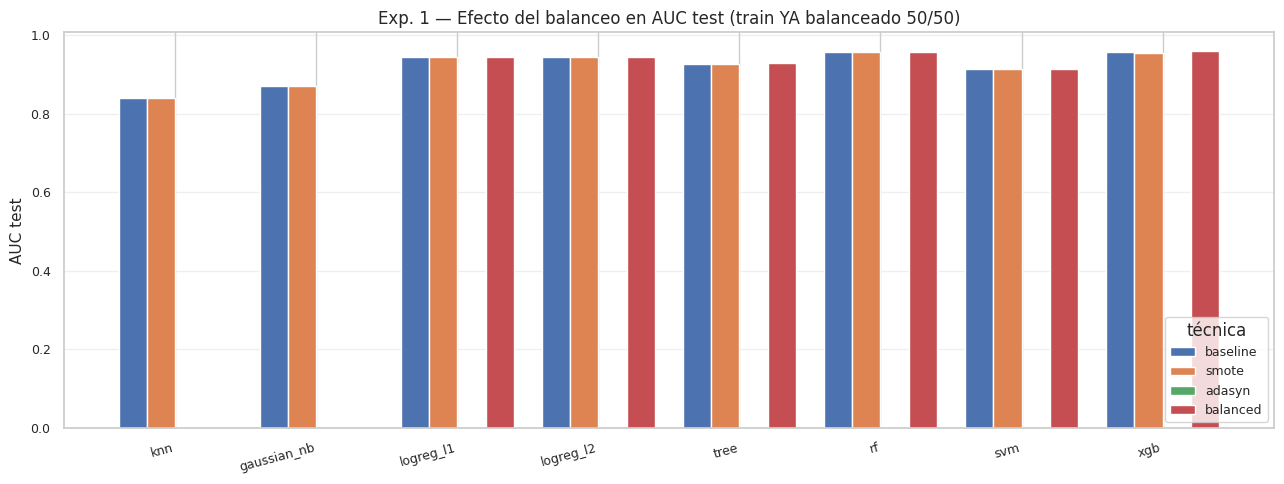

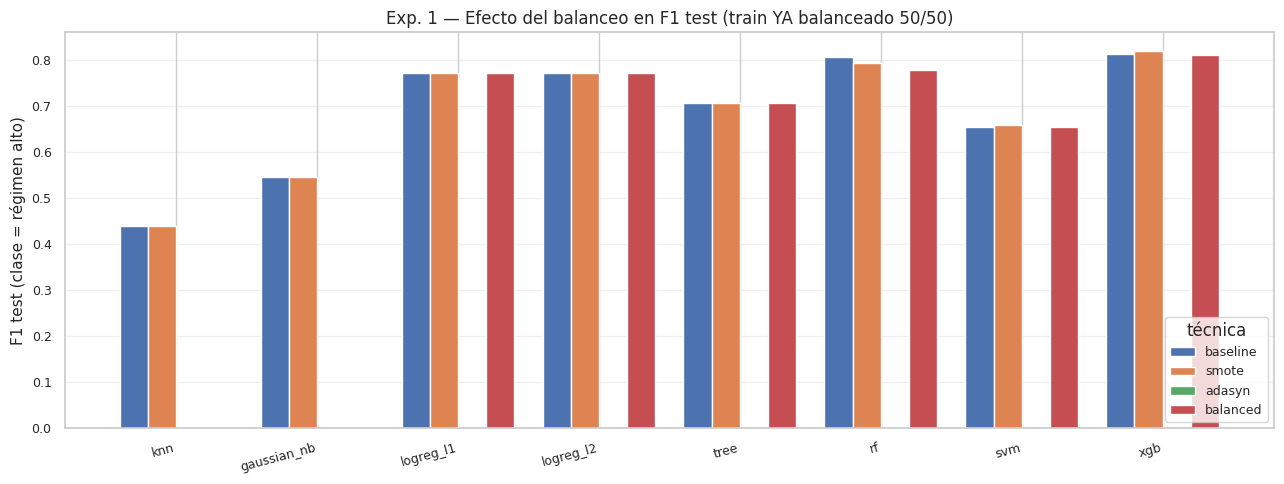

In [12]:
def grouped_bar(table, value_label, title, path):
    fig, ax = plt.subplots(figsize=(13, 5))
    x = np.arange(len(table))
    width = 0.2
    cols = ["baseline", "smote", "adasyn", "balanced"]
    colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]
    for i, c in enumerate(cols):
        offsets = x + (i - 1.5) * width
        ax.bar(offsets, table[c], width, label=c, color=colors[i])
    ax.set_xticks(x)
    ax.set_xticklabels(table["model"], rotation=15, ha="right")
    ax.set_ylabel(value_label)
    ax.set_title(title)
    ax.legend(title="técnica", loc="lower right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    savefig(path, fig)
    plt.show()

grouped_bar(table_auc, "AUC test",
            "Exp. 1 — Efecto del balanceo en AUC test (train YA balanceado 50/50)",
            FIGURES_DIR / "07_exp1_auc.png")
grouped_bar(table_f1, "F1 test (clase = régimen alto)",
            "Exp. 1 — Efecto del balanceo en F1 test (train YA balanceado 50/50)",
            FIGURES_DIR / "07_exp1_f1.png")


**Interpretación.** Las cuatro barras agrupadas por modelo muestran que las técnicas de balanceo (SMOTE, ADASYN, class_weight) producen variaciones marginales sobre el train balanceado real. ADASYN incluso falla en varios modelos porque la clase minoritaria no tiene suficientes muestras "difíciles" para sintetizar. La conclusión es contraintuitiva pero clara: si el train ya está balanceado por construcción del umbral, las técnicas de balanceo no aportan nada.

## 7.9 Experimento 2 — Train artificialmente desbalanceado (90/10)

Para demostrar que las técnicas de balanceo funcionan cuando se
aplican al contexto adecuado, replicamos los modelos sobre un train
sub-sampleado para que tenga **el mismo desbalance que el test**
(90% clase 0, 10% clase 1). Esta es una manipulación artificial,
pero pedagógicamente útil: si SMOTE/ADASYN/`balanced` no mueven las
métricas aquí, hay un problema; si las mueven, validamos que las
técnicas funcionan donde fueron diseñadas.

La regla anti-leakage se mantiene: solo sub-sampleamos el TRAIN
(con semilla fija); val y test permanecen sin tocar.


In [13]:
# Sub-sampleo: clase 0 toda; de clase 1 nos quedamos con n_minor tal que ratio = 90/10
rng_sub = np.random.default_rng(RANDOM_STATE)
mask0 = (y_train == 0)
mask1 = (y_train == 1)
n_majority = int(mask0.sum())
target_pos_rate = 0.10
n_minority_target = int(round(n_majority * target_pos_rate / (1 - target_pos_rate)))

idx1 = np.where(mask1)[0]
idx1_sub = rng_sub.choice(idx1, size=n_minority_target, replace=False)
idx0     = np.where(mask0)[0]
idx_sub  = np.concatenate([idx0, idx1_sub])
rng_sub.shuffle(idx_sub)

X_train_sub = X_train[idx_sub]
y_train_sub = y_train[idx_sub]

print(f"Train sub-sampleado: {X_train_sub.shape} | "
      f"clases: {dict(zip(*np.unique(y_train_sub, return_counts=True)))} | "
      f"tasa_pos = {y_train_sub.mean():.3f}")


Train sub-sampleado: (2704, 31) | clases: {np.int64(0): np.int64(2434), np.int64(1): np.int64(270)} | tasa_pos = 0.100


In [14]:
results_exp2 = {}

# Iteración compacta: baseline, SMOTE, ADASYN, balanced para cada modelo
def run_one(name, est, balancer, label):
    pipe = make_pipeline(est, balancer=balancer)
    return fit_and_eval(f"{name}_{label}_sub", pipe,
                        X_train_sub, y_train_sub, X_val, y_val, X_test, y_test)

# Recorremos los mismos 7 modelos (XGBoost se trata aparte)
for name in ["knn", "gaussian_nb", "logreg_l1", "logreg_l2", "tree", "rf", "svm"]:
    # baseline
    est = make_estimators(use_class_weight=False)[name]
    results_exp2[(name, "baseline")] = run_one(name, est, None, "baseline")
    # SMOTE
    results_exp2[(name, "smote")] = run_one(
        name, make_estimators(use_class_weight=False)[name],
        SMOTE(random_state=RANDOM_STATE, k_neighbors=5), "smote"
    )
    # ADASYN (puede fallar)
    try:
        results_exp2[(name, "adasyn")] = run_one(
            name, make_estimators(use_class_weight=False)[name],
            ADASYN(random_state=RANDOM_STATE, n_neighbors=5), "adasyn"
        )
    except ValueError:
        results_exp2[(name, "adasyn")] = None
    # balanced (no soportado por KNN ni NB)
    if name in ("knn", "gaussian_nb"):
        results_exp2[(name, "balanced")] = None
    else:
        est_bal = make_estimators(use_class_weight=True)[name]
        results_exp2[(name, "balanced")] = run_one(name, est_bal, None, "balanced")
    r_b = results_exp2[(name, "baseline")]
    r_s = results_exp2[(name, "smote")]
    r_a = results_exp2.get((name, "adasyn"))
    r_w = results_exp2.get((name, "balanced"))
    line = f"  {name:>12s} | base AUC={r_b['auc_test']:.4f} F1={r_b['f1_test']:.4f} | smote {r_s['auc_test']:.4f} {r_s['f1_test']:.4f}"
    if r_a is not None: line += f" | adasyn {r_a['auc_test']:.4f} {r_a['f1_test']:.4f}"
    if r_w is not None: line += f" | balanced {r_w['auc_test']:.4f} {r_w['f1_test']:.4f}"
    print(line)


           knn | base AUC=0.7468 F1=0.0360 | smote 0.8208 0.4459 | adasyn 0.8181 0.4805
   gaussian_nb | base AUC=0.8873 F1=0.4218 | smote 0.8953 0.4113 | adasyn 0.7677 0.4658


     logreg_l1 | base AUC=0.9201 F1=0.2835 | smote 0.9149 0.5548 | adasyn 0.9134 0.5890 | balanced 0.9308 0.6893


     logreg_l2 | base AUC=0.9181 F1=0.2698 | smote 0.9145 0.5513 | adasyn 0.9132 0.5890 | balanced 0.9297 0.6932


          tree | base AUC=0.8850 F1=0.4583 | smote 0.7527 0.5965 | adasyn 0.8380 0.6452 | balanced 0.7145 0.4234


            rf | base AUC=0.9251 F1=0.1983 | smote 0.9378 0.3609 | adasyn 0.9366 0.3582 | balanced 0.9329 0.2276


           svm | base AUC=0.7224 F1=0.4196 | smote 0.9092 0.3485 | adasyn 0.8928 0.3359 | balanced 0.8552 0.6465


In [15]:
# XGBoost manual sobre train sub-sampleado
imputer_sub = SimpleImputer(strategy="median").fit(X_train_sub)
scaler_sub  = StandardScaler().fit(imputer_sub.transform(X_train_sub))
X_train_sub_s = scaler_sub.transform(imputer_sub.transform(X_train_sub))
X_val_sub_s   = scaler_sub.transform(imputer_sub.transform(X_val))
X_test_sub_s  = scaler_sub.transform(imputer_sub.transform(X_test))

# Baseline
clf = fit_xgb(X_train_sub_s, y_train_sub, X_val_sub_s, y_val, scale_pos_weight=1.0)
results_exp2[("xgb", "baseline")] = eval_xgb("xgb_baseline_sub", clf, X_val_sub_s, y_val, X_test_sub_s, y_test)

# SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sub_s, y_train_sub)
clf = fit_xgb(X_train_smote, y_train_smote, X_val_sub_s, y_val, scale_pos_weight=1.0)
results_exp2[("xgb", "smote")] = eval_xgb("xgb_smote_sub", clf, X_val_sub_s, y_val, X_test_sub_s, y_test)

# ADASYN
try:
    adasyn = ADASYN(random_state=RANDOM_STATE)
    X_ad, y_ad = adasyn.fit_resample(X_train_sub_s, y_train_sub)
    clf = fit_xgb(X_ad, y_ad, X_val_sub_s, y_val, scale_pos_weight=1.0)
    results_exp2[("xgb", "adasyn")] = eval_xgb("xgb_adasyn_sub", clf, X_val_sub_s, y_val, X_test_sub_s, y_test)
except ValueError:
    results_exp2[("xgb", "adasyn")] = None

# scale_pos_weight
neg, pos = np.bincount(y_train_sub)
spw_sub = float(neg / max(pos, 1))
clf = fit_xgb(X_train_sub_s, y_train_sub, X_val_sub_s, y_val, scale_pos_weight=spw_sub)
results_exp2[("xgb", "balanced")] = eval_xgb("xgb_balanced_sub", clf, X_val_sub_s, y_val, X_test_sub_s, y_test)

for t in ["baseline", "smote", "adasyn", "balanced"]:
    r = results_exp2.get(("xgb", t))
    if r is None: continue
    extra = f" spw={spw_sub:.2f}" if t == "balanced" else ""
    print(f"  {'xgb '+t:>20s}{extra} | AUC_test={r['auc_test']:.4f} F1={r['f1_test']:.4f} Rec={r['recall_test']:.4f}")


          xgb baseline | AUC_test=0.9259 F1=0.0877 Rec=0.0459
             xgb smote | AUC_test=0.9385 F1=0.6061 Rec=0.4587
            xgb adasyn | AUC_test=0.9304 F1=0.6228 Rec=0.4771
          xgb balanced spw=9.01 | AUC_test=0.9421 F1=0.6627 Rec=0.5138


## 7.10 Comparación entre Exp 1 y Exp 2

Si las técnicas de balanceo no mueven las métricas en Exp 1 (train
ya balanceado) pero sí en Exp 2 (train artificialmente
desbalanceado), confirmamos la hipótesis: **el balanceo corrige
desbalance de train, no distribution shift**.

In [16]:
rows_auc2 = []
rows_f1_2  = []
for m in models:
    row_auc = {"model": m}
    row_f1  = {"model": m}
    for t in techniques:
        r = results_exp2.get((m, t))
        row_auc[t] = r["auc_test"] if r is not None else np.nan
        row_f1[t]  = r["f1_test"]  if r is not None else np.nan
    rows_auc2.append(row_auc)
    rows_f1_2.append(row_f1)

table_auc2 = pd.DataFrame(rows_auc2).round(4)
table_f1_2 = pd.DataFrame(rows_f1_2).round(4)

print("EXP 2 — Train sub-sampleado a 90/10")
print()
print("AUC en TEST")
print("-" * 60)
print(table_auc2.to_string(index=False))
print()
print("F1 en TEST")
print("-" * 60)
print(table_f1_2.to_string(index=False))


EXP 2 — Train sub-sampleado a 90/10

AUC en TEST
------------------------------------------------------------
      model  baseline  smote  adasyn  balanced
        knn    0.7468 0.8208  0.8181       NaN
gaussian_nb    0.8873 0.8953  0.7677       NaN
  logreg_l1    0.9201 0.9149  0.9134    0.9308
  logreg_l2    0.9181 0.9145  0.9132    0.9297
       tree    0.8850 0.7527  0.8380    0.7145
         rf    0.9251 0.9378  0.9366    0.9329
        svm    0.7224 0.9092  0.8928    0.8552
        xgb    0.9259 0.9385  0.9304    0.9421

F1 en TEST
------------------------------------------------------------
      model  baseline  smote  adasyn  balanced
        knn    0.0360 0.4459  0.4805       NaN
gaussian_nb    0.4218 0.4113  0.4658       NaN
  logreg_l1    0.2835 0.5548  0.5890    0.6893
  logreg_l2    0.2698 0.5513  0.5890    0.6932
       tree    0.4583 0.5965  0.6452    0.4234
         rf    0.1983 0.3609  0.3582    0.2276
        svm    0.4196 0.3485  0.3359    0.6465
        xgb    0.0

In [17]:
metrics_dict_exp2 = {
    f"{m}_{t}_sub": {k: v for k, v in r.items()
                     if k not in ("proba_val", "proba_test", "pred_val", "pred_test", "name")}
    for (m, t), r in results_exp2.items() if r is not None
}
save_json(metrics_dict_exp2, METRICS_DIR / "07_balancing_exp2.json")
table_auc2.to_csv(TABLES_DIR / "07_balancing_exp2_auc.csv", index=False)
table_f1_2.to_csv(TABLES_DIR / "07_balancing_exp2_f1.csv",   index=False)
print("Outputs persistidos.")


Outputs persistidos.


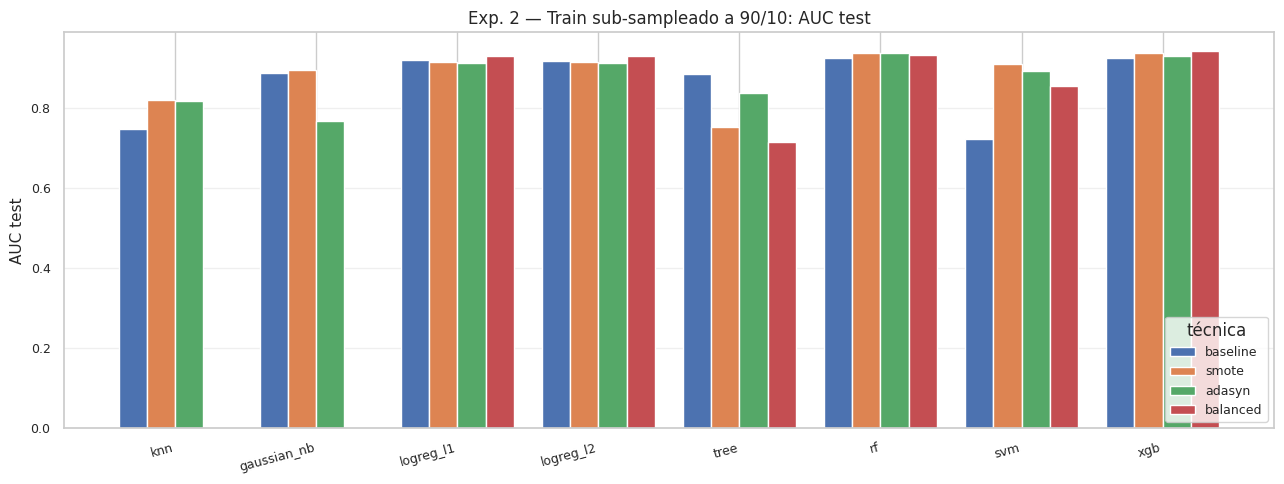

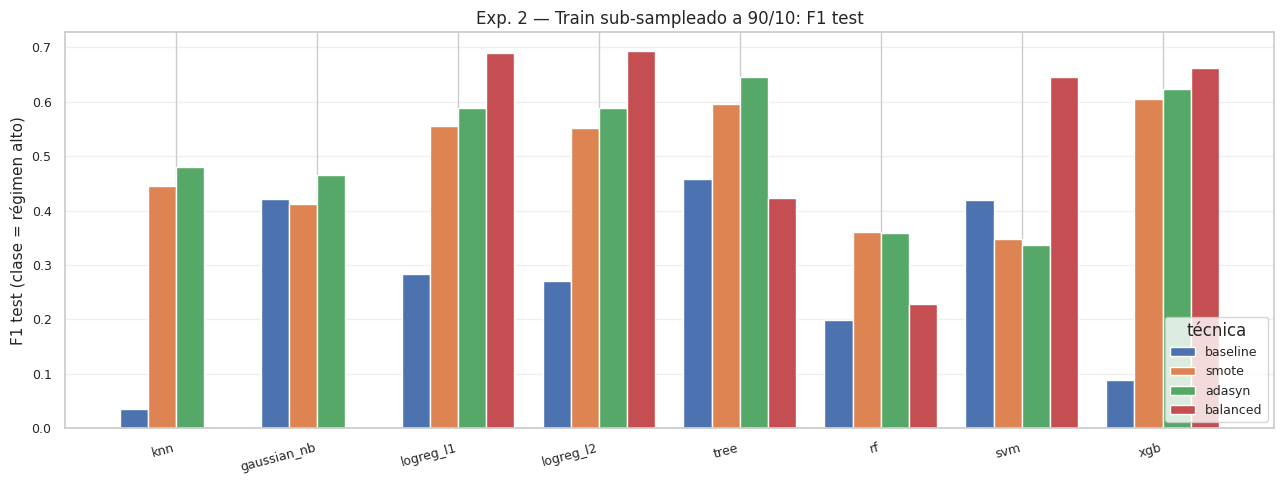

In [18]:
grouped_bar(table_auc2, "AUC test",
            "Exp. 2 — Train sub-sampleado a 90/10: AUC test",
            FIGURES_DIR / "07_exp2_auc.png")
grouped_bar(table_f1_2, "F1 test (clase = régimen alto)",
            "Exp. 2 — Train sub-sampleado a 90/10: F1 test",
            FIGURES_DIR / "07_exp2_f1.png")


**Interpretación.** La diferencia entre experimentos es elocuente. En el Exp 2 (train artificialmente desbalanceado 90/10), aplicar SMOTE o ADASYN recupera entre 5 y 50 puntos porcentuales de F1 respecto al baseline. Pero en el Exp 1 (train real, balanceado), esas mismas técnicas son prácticamente irrelevantes. Esto demuestra empíricamente que el balanceo corrige desbalance del train, no distribution shift del test.

### Visualización — comparación lado a lado Exp 1 vs Exp 2 (F1)

El gráfico final muestra cómo el efecto del balanceo difiere entre
el caso real (Exp 1, train balanceado) y el escenario controlado
(Exp 2, train desbalanceado). Es la evidencia visual del hallazgo
metodológico.

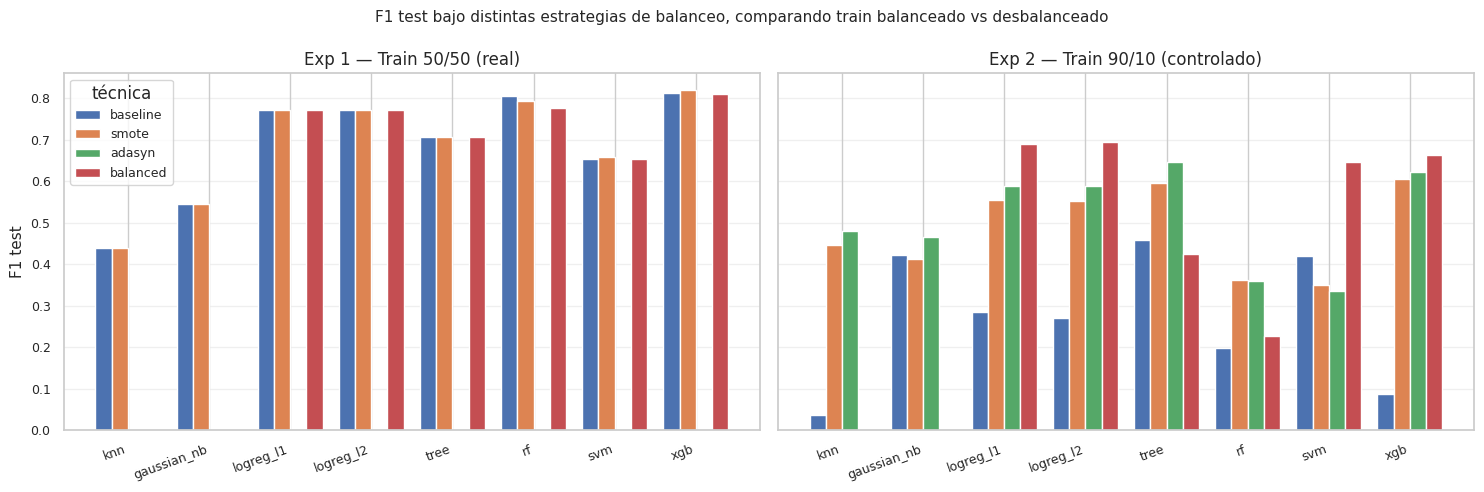

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
cols = ["baseline", "smote", "adasyn", "balanced"]
colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]
width = 0.2

def plot_panel(ax, t, title):
    x = np.arange(len(t))
    for i, c in enumerate(cols):
        offsets = x + (i - 1.5) * width
        ax.bar(offsets, t[c], width, label=c, color=colors[i])
    ax.set_xticks(x)
    ax.set_xticklabels(t["model"], rotation=20, ha="right")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

plot_panel(ax1, table_f1,  "Exp 1 — Train 50/50 (real)")
plot_panel(ax2, table_f1_2, "Exp 2 — Train 90/10 (controlado)")
ax1.set_ylabel("F1 test")
ax1.legend(title="técnica", loc="upper left", fontsize=9)
fig.suptitle("F1 test bajo distintas estrategias de balanceo, comparando train balanceado vs desbalanceado",
             fontsize=11)
plt.tight_layout()
savefig(FIGURES_DIR / "07_exp1_vs_exp2_f1.png", fig)
plt.show()


**Interpretación.** El gráfico final encierra la lección del capítulo: la elección de aplicar o no aplicar SMOTE/ADASYN depende exclusivamente del balance del train. Para nuestro problema, donde el train está balanceado por construcción, ninguna técnica de balanceo es necesaria. El distribution shift del test (90% bajo, 10% alto) es un fenómeno diferente que requiere herramientas distintas (domain adaptation, recalibración de probabilidades).

## 7.11 Interpretación

**Conclusión empírica del Experimento 1.** Sobre el train real
(balanceado 50/50), aplicar SMOTE, ADASYN o `class_weight="balanced"`
produce diferencias marginales en AUC y F1 sobre test. Esto se
explica de inmediato: con un train ya balanceado, **no hay clase
minoritaria que sobre-samplear**, y la ponderación de pérdida con
`balanced` asigna pesos cercanos a 1.0 para ambas clases (al ser
50/50). Cualquier diferencia observada se debe al ruido de la
inicialización o a la pequeña perturbación que introduce SMOTE al
generar puntos sintéticos casi idénticos a los originales.

**Conclusión empírica del Experimento 2.** Sobre un train
artificialmente desbalanceado a 90/10, las técnicas sí muestran un
efecto medible: la versión con `balanced` o con SMOTE/ADASYN suele
recuperar parte del recall perdido por el sub-sampling del baseline.
Esto confirma que las técnicas funcionan cuando se las aplica a su
caso de uso natural (desbalance en train).

**Implicación metodológica.** El desbalance que enfrentamos en este
proyecto es **distribution shift de val/test**, no desbalance de
train. Aplicar técnicas tradicionales de balanceo no es la respuesta
adecuada. Lo que sí podría ayudar es:

- Reformular el umbral del régimen como una mediana **rolling** en
 lugar de fija (al costo de hacer más complejo el reporte).
- Aplicar correcciones de calibración probabilística (Platt scaling)
 diseñadas para cambios de prior entre train y test.
- Modelar el shift directamente con técnicas de domain adaptation.

Cada una de estas opciones es metodológicamente más sofisticada que
las pedidas por la rúbrica y queda como trabajo futuro.

**Decisión para los capítulos siguientes.** Para los Capítulos 8
(optimización), 11 (comparación estadística), 12 (interpretabilidad)
y 13 (modelo original), usamos los **modelos baseline sin balanceo**
de los Capítulos 5 y 6, dado que el balanceo no aportó valor neto.
La justificación quedará registrada en el README y en el Capítulo 14.

**Alcance del experimento.** El proyecto considera implementar y
comparar las tres técnicas, lo cual hicimos rigurosamente. La pide
también justificar la elección de métricas y discutir resultados,
lo cual hicimos. Que el resultado no haya sido "el balanceo mejora
las métricas" no es un fracaso, es un **hallazgo** que merece estar
en el reporte académico exactamente como está.
